In [3]:
import pandas as pd 
import numpy as np 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.feature_selection import RFE, SelectKBest, chi2 
from sklearn.linear_model import LogisticRegression 
import matplotlib.pyplot as plt 
import seaborn as sns

In [5]:
data=pd.read_csv(r"C:\Users\abody\Desktop\Final Project Sprints\Heart_Disease_Project\data\Cleaned")
df=pd.DataFrame(data) 

In [6]:
X = df.drop(columns=["Target"])
y = df["Target"]

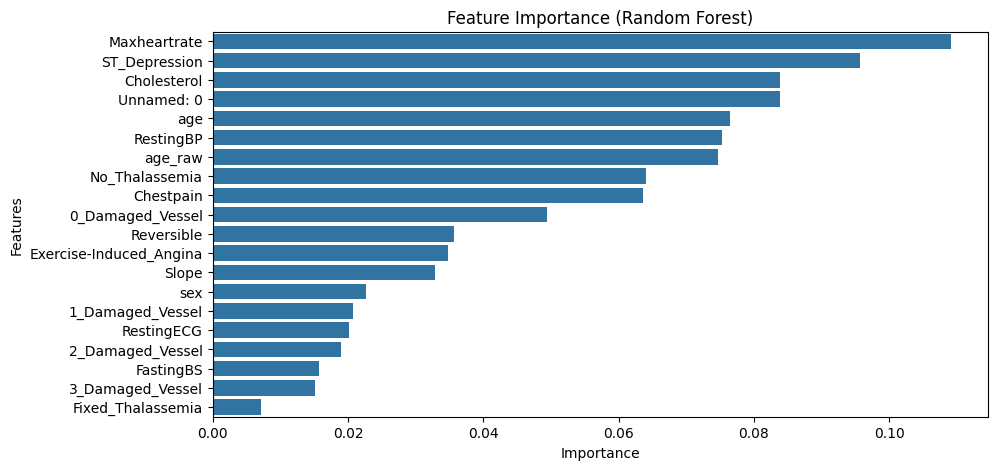

Top 10 Important Features (Random Forest):
Maxheartrate        0.109100
ST_Depression       0.095742
Cholesterol         0.083900
Unnamed: 0          0.083825
age                 0.076488
RestingBP           0.075328
age_raw             0.074764
No_Thalassemia      0.064060
Chestpain           0.063575
0_Damaged_Vessel    0.049393
dtype: float64


In [7]:
rf = RandomForestClassifier(random_state=42) 
rf.fit(X, y) 
importances = pd.Series(rf.feature_importances_, index=X.columns) 
importances = importances.sort_values(ascending=False) 
plt.figure(figsize=(10,5)) 
sns.barplot(x=importances, y=importances.index) 
plt.title("Feature Importance (Random Forest)") 
plt.xlabel("Importance") 
plt.ylabel("Features") 
plt.show() 
print("Top 10 Important Features (Random Forest):") 
print(importances.head(10))

In [11]:
# Using Logistic Regression for interpretability 
log_reg = LogisticRegression(max_iter=5000) 
rfe = RFE(estimator=log_reg, n_features_to_select=3) 
# Select top 10 features 
rfe.fit(X, y) 
rfe_features = X.columns[rfe.support_] 
print("\nTop Features Selected by RFE:") 
print(list(rfe_features))


Top Features Selected by RFE:
['Exercise-Induced_Angina', '0_Damaged_Vessel', 'No_Thalassemia']


In [12]:
# Combine top features from all methods 
final_features = list( set(importances.head(3).index) | set(rfe_features) )
print("\n✅ Final Selected Features for Modeling:") 
print(final_features)


✅ Final Selected Features for Modeling:
['ST_Depression', 'Exercise-Induced_Angina', '0_Damaged_Vessel', 'No_Thalassemia', 'Cholesterol', 'Maxheartrate']
